# Analysis of nuclide and flux relaxation in RM schemes

In [1]:
import CustomSchemes
from CustomSchemes import SIE
from CustomSchemes.SIE import load_SIE as load_SIE
import matplotlib.pyplot as plt

In [2]:
the_file = SIE.SIE().get_from_pkl("FLUX.pkl")

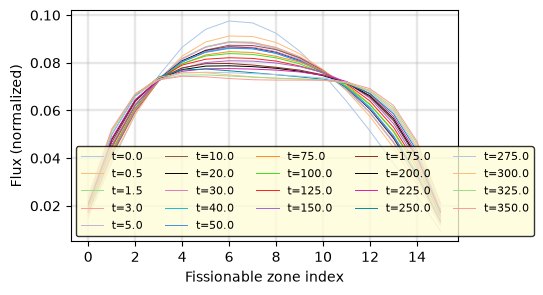

In [3]:
the_file.plot_all_x()

/Users/4yf/projects/MonteCarloXenon/CustomSchemes/Colors.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(edgecolor='black', facecolor=Colors.manilla(), **kwargs)


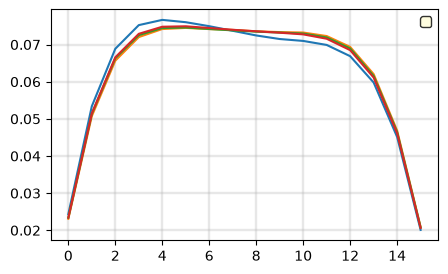

In [9]:
plt.figure(figsize=(5,3))
for this in the_file.get_x_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

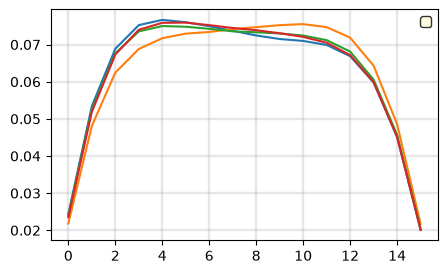

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_fx_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [13]:
the_file.x[0.0][0]


array([0.01518952, 0.03807338, 0.05828538, 0.0745936 , 0.08652256,
       0.09405829, 0.09754185, 0.09672806, 0.09239911, 0.0849253 ,
       0.07524054, 0.06381959, 0.05135369, 0.03788274, 0.02395908,
       0.00942733])

# Anderson Acceleration analysis

In [8]:
from CustomSchemes.AA import Anderson as Anderson
import matplotlib.pyplot as plt
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')

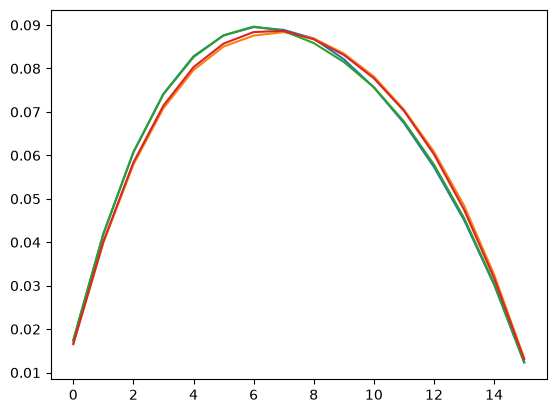

In [13]:
time = 3.0
for this in aa.fx[time]:
  plt.plot(this)

In [ ]:
aa.get

{0.5: array([0.25360242, 0.47747868, 0.2689189 ]),
 1.5: array([0.06751126, 0.86953524, 0.0629535 ]),
 3.0: array([-0.21181425,  0.51143081,  0.70038344])}

Computed fixed point (last x_next) =  [0.01700528 0.04111287 0.05968719 0.07293794 0.08163242 0.08684668
 0.08919864 0.08871167 0.08623083 0.08222392 0.07660702 0.06893634
 0.05890246 0.04631022 0.03097078 0.01268574]
Last n_next value from vector x =  [0.01700528 0.04111287 0.05968719 0.07293794 0.08163242 0.08684668
 0.08919864 0.08871167 0.08623083 0.08222392 0.07660702 0.06893634
 0.05890246 0.04631022 0.03097078 0.01268574]
Iterations: 4
Alpha sums are == 1.0
Alphas = [-0.21181425  0.51143081  0.70038344]


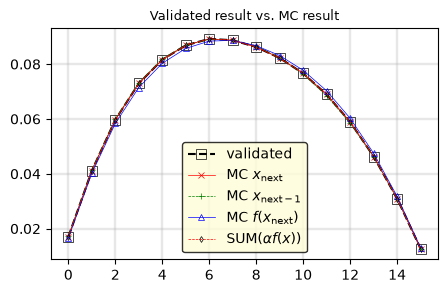

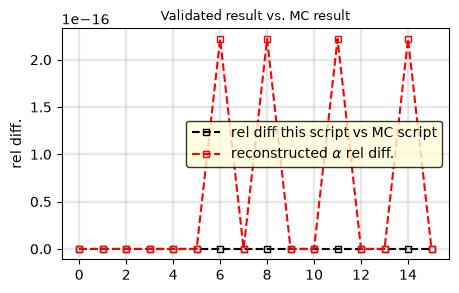

In [12]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=3.0, file='aa2_i4_t3.pkl', k_max=4, m=2, dpi=100)

# Visual comparison of each

In [29]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')
flux = SIE().get_from_pkl('FLUX.pkl')
nuclide = SIE().get_from_pkl('NUCLIDE.pkl')


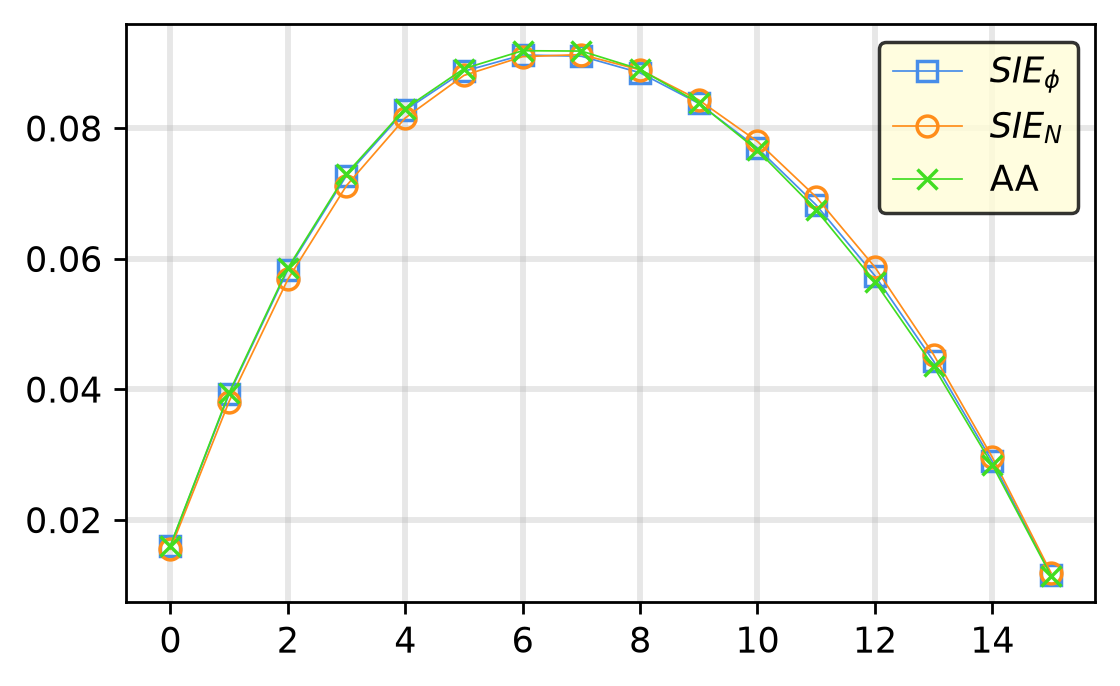

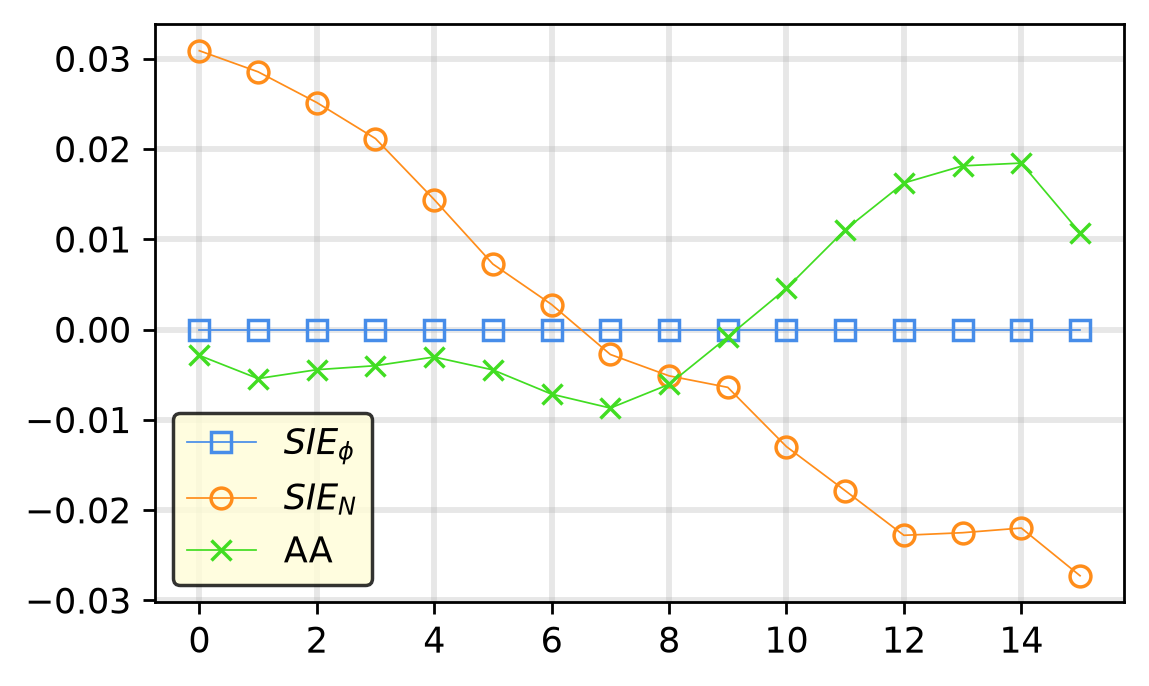

In [31]:
def difference(x, ref) -> np.ndarray:
  return np.array([1-x[idx]/ref[idx] for idx in range(len(ref))])

time = 0.5
plt.figure(figsize=(5,3), dpi=250)
plt.plot(flux.x[time][-1], 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(nuclide.x[time][-1], 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(aa.x[time][-1], 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()

time = 0.5
ref = flux.x[time][-1]
aa_x = aa.x[time][-1]
nuc_x = nuclide.x[time][-1]

plt.figure(figsize=(5,3), dpi=250)
plt.plot(difference(ref, ref), 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(difference(nuc_x, ref), 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(difference(aa_x, ref), 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()
